# Analyse Complète des Prix Mobiles



## 0. Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from scipy.stats import (
    f_oneway, kruskal, pearsonr, spearmanr,
    normaltest, levene, chi2_contingency
)
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.edgecolor"   : "#cccccc",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "text.color"       : "#222222",
    "axes.labelcolor"  : "#222222",
    "xtick.color"      : "#555555",
    "ytick.color"      : "#555555",
    "grid.color"       : "#eeeeee",
    "grid.linestyle"   : "-",
    "grid.alpha"       : 0.7,
    "figure.dpi"       : 110,
    "font.size"        : 10,
})

# Palette par classe de prix
COULEURS_PRIX = {0: "#2196F3", 1: "#4CAF50", 2: "#FF9800", 3: "#F44336"}
LABELS_PRIX   = {0: "Bas (0)", 1: "Moyen-bas (1)", 2: "Moyen-haut (2)", 3: "Haut (3)"}

print("Bibliotheques importees.")


Bibliotheques importees.


---
## 1. Chargement et Exploration des Données

### 1.1 Chargement du jeu de données


In [2]:
df = pd.read_csv("train.csv")

print("Dimensions :", df.shape)
print("Lignes     :", df.shape[0], " | Colonnes :", df.shape[1])
print()
df.head(6)


Dimensions : (2000, 21)
Lignes     : 2000  | Colonnes : 21



,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
5,1859,0,0.5,1,3,0,22,0.7,164,1,...,1004,1654,1067,17,1,10,1,0,0,1


### 1.2 Structure et types de données

In [3]:
print("Types de donnees :")
print(df.dtypes)
print()

# Distinction numerique continu / binaire / cible
binaires   = ["blue", "dual_sim", "four_g", "three_g", "touch_screen", "wifi"]
continues  = ["battery_power", "clock_speed", "fc", "int_memory", "m_dep",
              "mobile_wt", "n_cores", "pc", "px_height", "px_width",
              "ram", "sc_h", "sc_w", "talk_time"]
cible      = "price_range"

print("Variables binaires  ({}) :".format(len(binaires)),  binaires)
print("Variables continues ({}) :".format(len(continues)), continues)
print("Variable cible      : price_range  (0=bas, 1=moyen-bas, 2=moyen-haut, 3=haut)")


Types de donnees :
battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object

Variables binaires  (6) : ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']
Variables continues (14) : ['battery_power', 'clock_speed', 'fc', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time']
Variable cible      : price_range  (0=bas, 1=moyen-bas, 2=moyen-haut, 3=haut)


### 1.3 Statistiques descriptives globales

In [4]:
desc = df.describe().round(2)
print(desc.to_string())


       battery_power    blue  clock_speed  dual_sim       fc   four_g  int_memory    m_dep  mobile_wt  n_cores       pc  px_height  px_width      ram     sc_h     sc_w  talk_time  three_g  touch_screen     wifi  price_range
count        2000.00  2000.0      2000.00   2000.00  2000.00  2000.00     2000.00  2000.00    2000.00  2000.00  2000.00    2000.00   2000.00  2000.00  2000.00  2000.00    2000.00  2000.00        2000.0  2000.00      2000.00
mean         1238.52     0.5         1.52      0.51     4.31     0.52       32.05     0.50     140.25     4.52     9.92     645.11   1251.52  2124.21    12.31     5.77      11.01     0.76           0.5     0.51         1.50
std           439.42     0.5         0.82      0.50     4.34     0.50       18.15     0.29      35.40     2.29     6.06     443.78    432.20  1084.73     4.21     4.36       5.46     0.43           0.5     0.50         1.12
min           501.00     0.0         0.50      0.00     0.00     0.00        2.00     0.10      80.00   

### 1.4 Distribution de la variable cible

In [5]:
print("Repartition de price_range :")
print(df["price_range"].value_counts().sort_index().to_string())
print()
pct = df["price_range"].value_counts(normalize=True).sort_index() * 100
print("En pourcentage :")
for k, v in pct.items():
    print("  Classe {} : {:.1f}%".format(k, v))


Repartition de price_range :
price_range
0    500
1    500
2    500
3    500

En pourcentage :
  Classe 0 : 25.0%
  Classe 1 : 25.0%
  Classe 2 : 25.0%
  Classe 3 : 25.0%


---
## 2. Nettoyage des Données et Prétraitement

### 2.1 Valeurs manquantes


In [6]:
nulls = df.isnull().sum()
print("Valeurs manquantes par colonne :")
print(nulls[nulls > 0] if nulls.sum() > 0 else "  Aucune valeur manquante detectee.")
print()
print("Total cellules nulles :", df.isnull().sum().sum())


Valeurs manquantes par colonne :
  Aucune valeur manquante detectee.

Total cellules nulles : 0


### 2.2 Valeurs aberrantes — px_height

In [7]:
print("Statistiques de px_height :")
print("  Min    :", df["px_height"].min())
print("  Max    :", df["px_height"].max())
print("  Zeros  :", (df["px_height"] == 0).sum())

# Remplacer les zeros par la mediane par classe de prix
mediane_par_classe = df.groupby("price_range")["px_height"].median()
masque_zero = df["px_height"] == 0

df["px_height"] = df.apply(
    lambda row: mediane_par_classe[row["price_range"]]
    if row["px_height"] == 0 else row["px_height"],
    axis=1
)

print()
print("Apres correction (imputation par mediane de classe) :")
print("  Zeros restants  :", (df["px_height"] == 0).sum())
print("  Min px_height   :", df["px_height"].min())


Statistiques de px_height :
  Min    : 0
  Max    : 1960
  Zeros  : 2

Apres correction (imputation par mediane de classe) :
  Zeros restants  : 0
  Min px_height   : 1.0


### 2.3 Encodage et ajout de features dérivées

In [8]:
# Les variables binaires sont deja en 0/1 — pas d'encodage supplementaire necessaire.
# Ajout de la surface d'ecran (produit largeur x hauteur de pixels) pour enrichir l'analyse.
df["px_area"] = df["px_width"] * df["px_height"]

# Ratio batterie / poids
df["battery_per_gram"] = df["battery_power"] / df["mobile_wt"]

print("Colonnes apres pretraitement :", df.shape[1])
print("Nouvelles features : px_area, battery_per_gram")
df[["px_area", "battery_per_gram"]].describe().round(2)


Colonnes apres pretraitement : 23
Nouvelles features : px_area, battery_per_gram


,px_area,battery_per_gram
count,2000.00,2000.00
mean,906230.85,9.46
std,829352.20,4.30
min,926.00,2.52
25%,264144.00,6.18
50%,604032.00,8.85
75%,1359027.25,11.93
max,3886306.00,24.78


---
## 3. Analyse Statistique avec NumPy et SciPy

### 3.1 Mesures de tendance centrale, variabilité et forme de distribution


In [9]:
vars_analyse = ["battery_power", "clock_speed", "int_memory", "mobile_wt",
                "pc", "px_height", "px_width", "ram", "sc_h", "sc_w",
                "talk_time", "fc", "n_cores"]

resultats = []
for col in vars_analyse:
    serie = df[col].values
    mode_val = stats.mode(serie, keepdims=True).mode[0]
    resultats.append({
        "Feature"     : col,
        "Moyenne"     : round(np.mean(serie), 2),
        "Mediane"     : round(np.median(serie), 2),
        "Mode"        : mode_val,
        "Etendue"     : round(np.ptp(serie), 2),
        "Variance"    : round(np.var(serie, ddof=1), 2),
        "Ecart-type"  : round(np.std(serie, ddof=1), 2),
        "Asymetrie"   : round(stats.skew(serie), 3),
        "Kurtosis"    : round(stats.kurtosis(serie), 3),
    })

tableau = pd.DataFrame(resultats).set_index("Feature")
print(tableau.to_string())


               Moyenne  Mediane    Mode  Etendue    Variance  Ecart-type  Asymetrie  Kurtosis
Feature                                                                                      
battery_power  1238.52   1226.0   618.0   1497.0   193088.36      439.42      0.032    -1.224
clock_speed       1.52      1.5     0.5      2.5        0.67        0.82      0.178    -1.323
int_memory       32.05     32.0    27.0     62.0      329.27       18.15      0.058    -1.216
mobile_wt       140.25    141.0   182.0    120.0     1253.14       35.40      0.007    -1.210
pc                9.92     10.0    10.0     20.0       36.78        6.06      0.017    -1.172
px_height       645.75    568.0   347.0   1959.0   196525.81      443.31      0.667    -0.315
px_width       1251.52   1247.0   874.0   1498.0   186796.36      432.20      0.015    -1.186
ram            2124.21   2146.5  1229.0   3742.0  1176643.61     1084.73      0.007    -1.192
sc_h             12.31     12.0    17.0     14.0       17.75

### 3.2 Tests d'hypothèses — ANOVA et Kruskal-Wallis entre classes de prix

In [10]:
vars_test = ["battery_power", "ram", "px_height", "px_width",
             "int_memory", "mobile_wt", "clock_speed", "talk_time"]

groupes = [df.loc[df["price_range"] == k, :] for k in range(4)]

print("ANOVA et Kruskal-Wallis — Differences entre classes de prix")
print("H0 : les 4 classes ont la meme moyenne / distribution")
print("-" * 72)
en_tete = f"{'Feature':<18} {'F (ANOVA)':>12} {'p ANOVA':>12} {'H (KW)':>10} {'p KW':>12}  Conclusion"
print(en_tete)
print("-" * 72)

for col in vars_test:
    echantillons = [g[col].values for g in groupes]
    F, p_anova = f_oneway(*echantillons)
    H, p_kw    = kruskal(*echantillons)
    conclusion = "Significatif" if p_anova < 0.05 else "Non significatif"
    print(f"  {col:<16} {F:>12.2f} {p_anova:>12.4f} {H:>10.2f} {p_kw:>12.4f}  {conclusion}")

print()
print("Seuil alpha = 0.05")


ANOVA et Kruskal-Wallis — Differences entre classes de prix
H0 : les 4 classes ont la meme moyenne / distribution
------------------------------------------------------------------------
Feature               F (ANOVA)      p ANOVA     H (KW)         p KW  Conclusion
------------------------------------------------------------------------
  battery_power           31.60       0.0000      90.14       0.0000  Significatif
  ram                   3520.11       0.0000    1681.50       0.0000  Significatif
  px_height               19.82       0.0000      48.35       0.0000  Significatif
  px_width                22.62       0.0000      65.23       0.0000  Significatif
  int_memory               2.92       0.0328       8.77       0.0325  Significatif


  mobile_wt                3.59       0.0131      10.82       0.0127  Significatif
  clock_speed              0.49       0.6867       1.27       0.7358  Non significatif
  talk_time                1.63       0.1807       4.90       0.1796  Non significatif

Seuil alpha = 0.05


### 3.3 Corrélations avec la variable cible

In [11]:
print("Correlations avec price_range")
print("-" * 55)
print(f"{'Feature':<20} {'Pearson r':>10} {'p Pearson':>12} {'Spearman r':>11} {'p Spearman':>12}")
print("-" * 55)

resultats_corr = []
for col in continues + ["px_area", "battery_per_gram"]:
    r_p, p_p = pearsonr(df[col], df["price_range"])
    r_s, p_s = spearmanr(df[col], df["price_range"])
    resultats_corr.append((col, r_p, p_p, r_s, p_s))
    print(f"  {col:<18} {r_p:>10.4f} {p_p:>12.4f} {r_s:>11.4f} {p_s:>12.4f}")

resultats_corr.sort(key=lambda x: abs(x[1]), reverse=True)
print()
print("Top 5 correlations (Pearson |r|) :")
for col, r_p, p_p, r_s, p_s in resultats_corr[:5]:
    print("  {:18s}  r={:.4f}".format(col, r_p))


Correlations avec price_range
-------------------------------------------------------
Feature               Pearson r    p Pearson  Spearman r   p Spearman
-------------------------------------------------------
  battery_power          0.2007       0.0000      0.2000       0.0000
  clock_speed           -0.0066       0.7678     -0.0054       0.8080


  fc                     0.0220       0.3255      0.0242       0.2800
  int_memory             0.0444       0.0469      0.0443       0.0477
  m_dep                  0.0009       0.9696     -0.0003       0.9885
  mobile_wt             -0.0303       0.1755     -0.0302       0.1768
  n_cores                0.0044       0.8441      0.0047       0.8353
  pc                     0.0336       0.1331      0.0328       0.1423
  px_height              0.1497       0.0000      0.1330       0.0000
  px_width               0.1658       0.0000      0.1651       0.0000
  ram                    0.9170       0.0000      0.9171       0.0000
  sc_h                   0.0230       0.3042      0.0237       0.2889
  sc_w                   0.0387       0.0835      0.0248       0.2681
  talk_time              0.0219       0.3285      0.0221       0.3224
  px_area                0.1772       0.0000      0.1593       0.0000
  battery_per_gram       0.1770       0.0000      0.1849       0.0000

Top 5 correlations 

### 3.4 Tests statistiques avancés — Chi2 pour variables binaires et test de Levene

In [12]:
print("Test du Chi2 — Variables binaires vs price_range")
print("-" * 52)
print(f"{'Variable':<16} {'Chi2':>10} {'p-value':>12} {'dof':>5}  Conclusion")
print("-" * 52)

for col in binaires:
    table = pd.crosstab(df[col], df["price_range"])
    chi2, p, dof, _ = chi2_contingency(table)
    conclusion = "Associe" if p < 0.05 else "Independant"
    print(f"  {col:<14} {chi2:>10.3f} {p:>12.4f} {dof:>5}  {conclusion}")

print()
print("Test de Levene — Homogeneite des variances de la RAM entre classes")
groupes_ram = [df.loc[df["price_range"] == k, "ram"].values for k in range(4)]
stat_lev, p_lev = levene(*groupes_ram)
print("  Levene stat : {:.4f}  |  p-value : {:.4f}".format(stat_lev, p_lev))
print("  Conclusion  :", "Variances heterogenes" if p_lev < 0.05 else "Variances homogenes")


Test du Chi2 — Variables binaires vs price_range
----------------------------------------------------
Variable               Chi2      p-value   dof  Conclusion
----------------------------------------------------
  blue                1.432       0.6980     3  Independant


  dual_sim            1.286       0.7323     3  Independant


  four_g              3.180       0.3647     3  Independant
  three_g             1.374       0.7117     3  Independant


  touch_screen        3.880       0.2747     3  Independant


  wifi                0.856       0.8360     3  Independant

Test de Levene — Homogeneite des variances de la RAM entre classes
  Levene stat : 16.3302  |  p-value : 0.0000
  Conclusion  : Variances heterogenes


### 3.5 Statistiques par classe de prix

In [13]:
vars_resume = ["battery_power", "ram", "px_height", "px_width", "int_memory",
               "clock_speed", "mobile_wt", "talk_time", "fc", "pc"]

for classe in range(4):
    sous_df = df[df["price_range"] == classe]
    print("Classe {} — {} (n={})".format(classe, LABELS_PRIX[classe], len(sous_df)))
    print("  RAM moy.      : {:.0f} Mo".format(sous_df["ram"].mean()))
    print("  Batterie moy. : {:.0f} mAh".format(sous_df["battery_power"].mean()))
    print("  Resolution    : {:.0f} x {:.0f} px".format(
        sous_df["px_width"].mean(), sous_df["px_height"].mean()))
    print("  Memoire int.  : {:.0f} Go".format(sous_df["int_memory"].mean()))
    print()


Classe 0 — Bas (0) (n=500)
  RAM moy.      : 785 Mo
  Batterie moy. : 1117 mAh
  Resolution    : 1150 x 536 px
  Memoire int.  : 31 Go

Classe 1 — Moyen-bas (1) (n=500)
  RAM moy.      : 1679 Mo
  Batterie moy. : 1229 mAh
  Resolution    : 1252 x 668 px
  Memoire int.  : 32 Go

Classe 2 — Moyen-haut (2) (n=500)
  RAM moy.      : 2583 Mo
  Batterie moy. : 1228 mAh
  Resolution    : 1234 x 632 px
  Memoire int.  : 31 Go

Classe 3 — Haut (3) (n=500)
  RAM moy.      : 3449 Mo
  Batterie moy. : 1380 mAh
  Resolution    : 1370 x 746 px
  Memoire int.  : 34 Go



---
## 4. Visualisation des Données avec Matplotlib

### 4.1 Histogrammes des variables continues par classe de prix


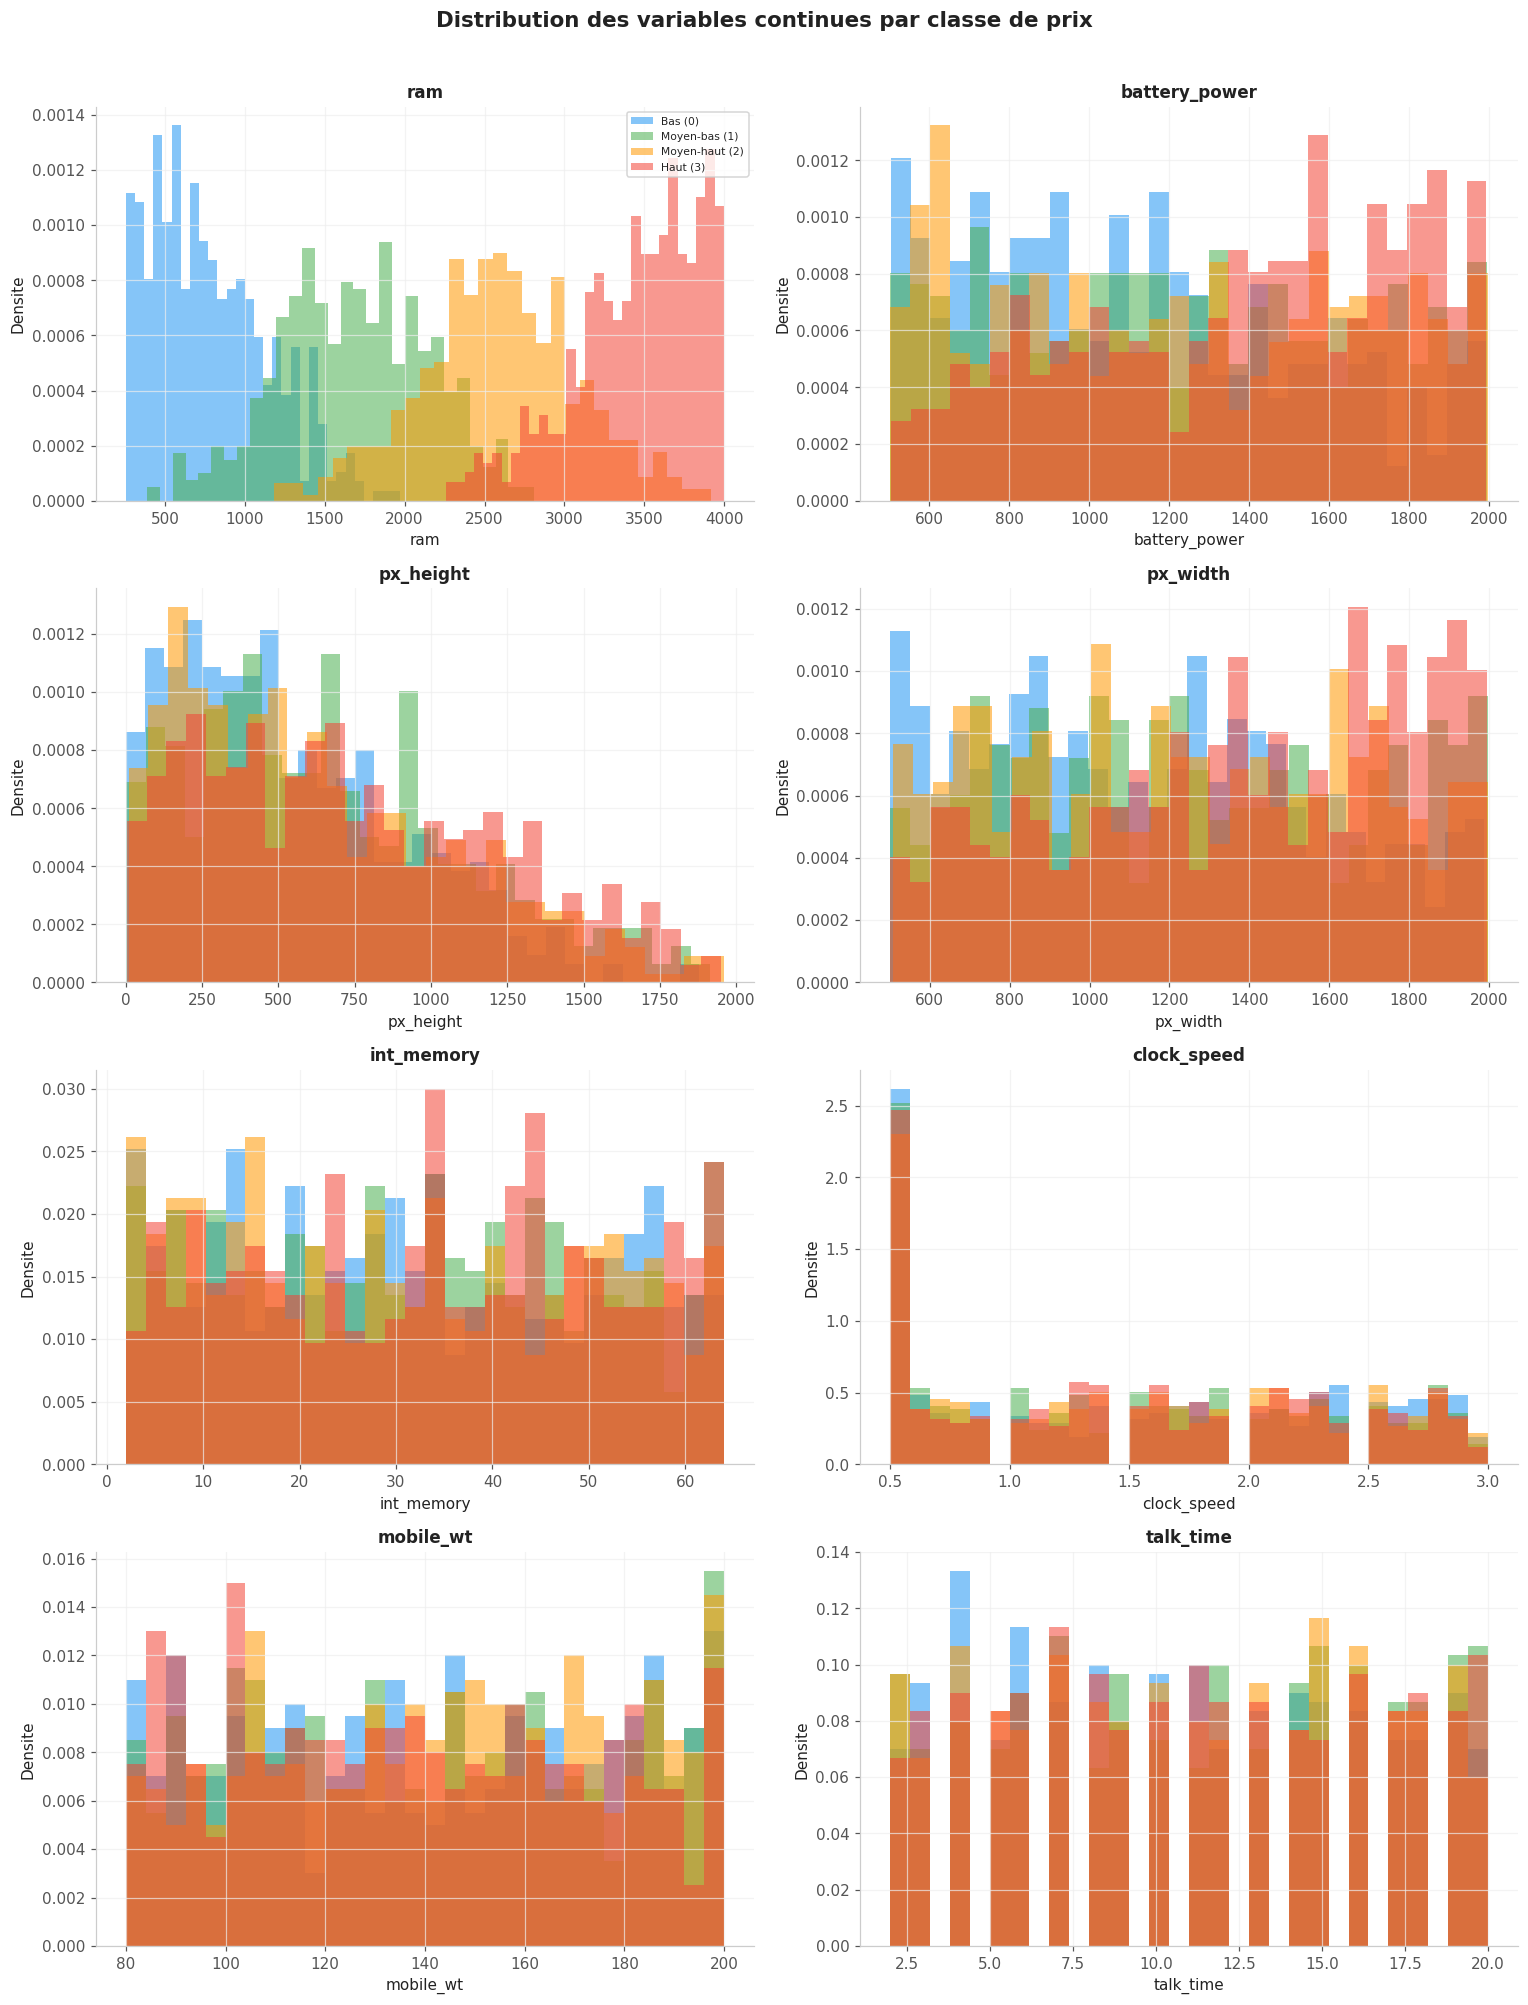

In [14]:
vars_hist = ["ram", "battery_power", "px_height", "px_width",
             "int_memory", "clock_speed", "mobile_wt", "talk_time"]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
fig.suptitle("Distribution des variables continues par classe de prix",
             fontsize=14, fontweight="bold", y=1.01)

for ax, col in zip(axes.flat, vars_hist):
    for classe in range(4):
        valeurs = df.loc[df["price_range"] == classe, col]
        ax.hist(valeurs, bins=30, alpha=0.55, color=COULEURS_PRIX[classe],
                label=LABELS_PRIX[classe], density=True, edgecolor="none")
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Densite")
    ax.grid(True)
    if col == "ram":
        ax.legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.savefig("fig1_histogrammes.png", bbox_inches="tight")
plt.show()


### 4.2 Boîtes à moustaches — Variables clés par classe de prix

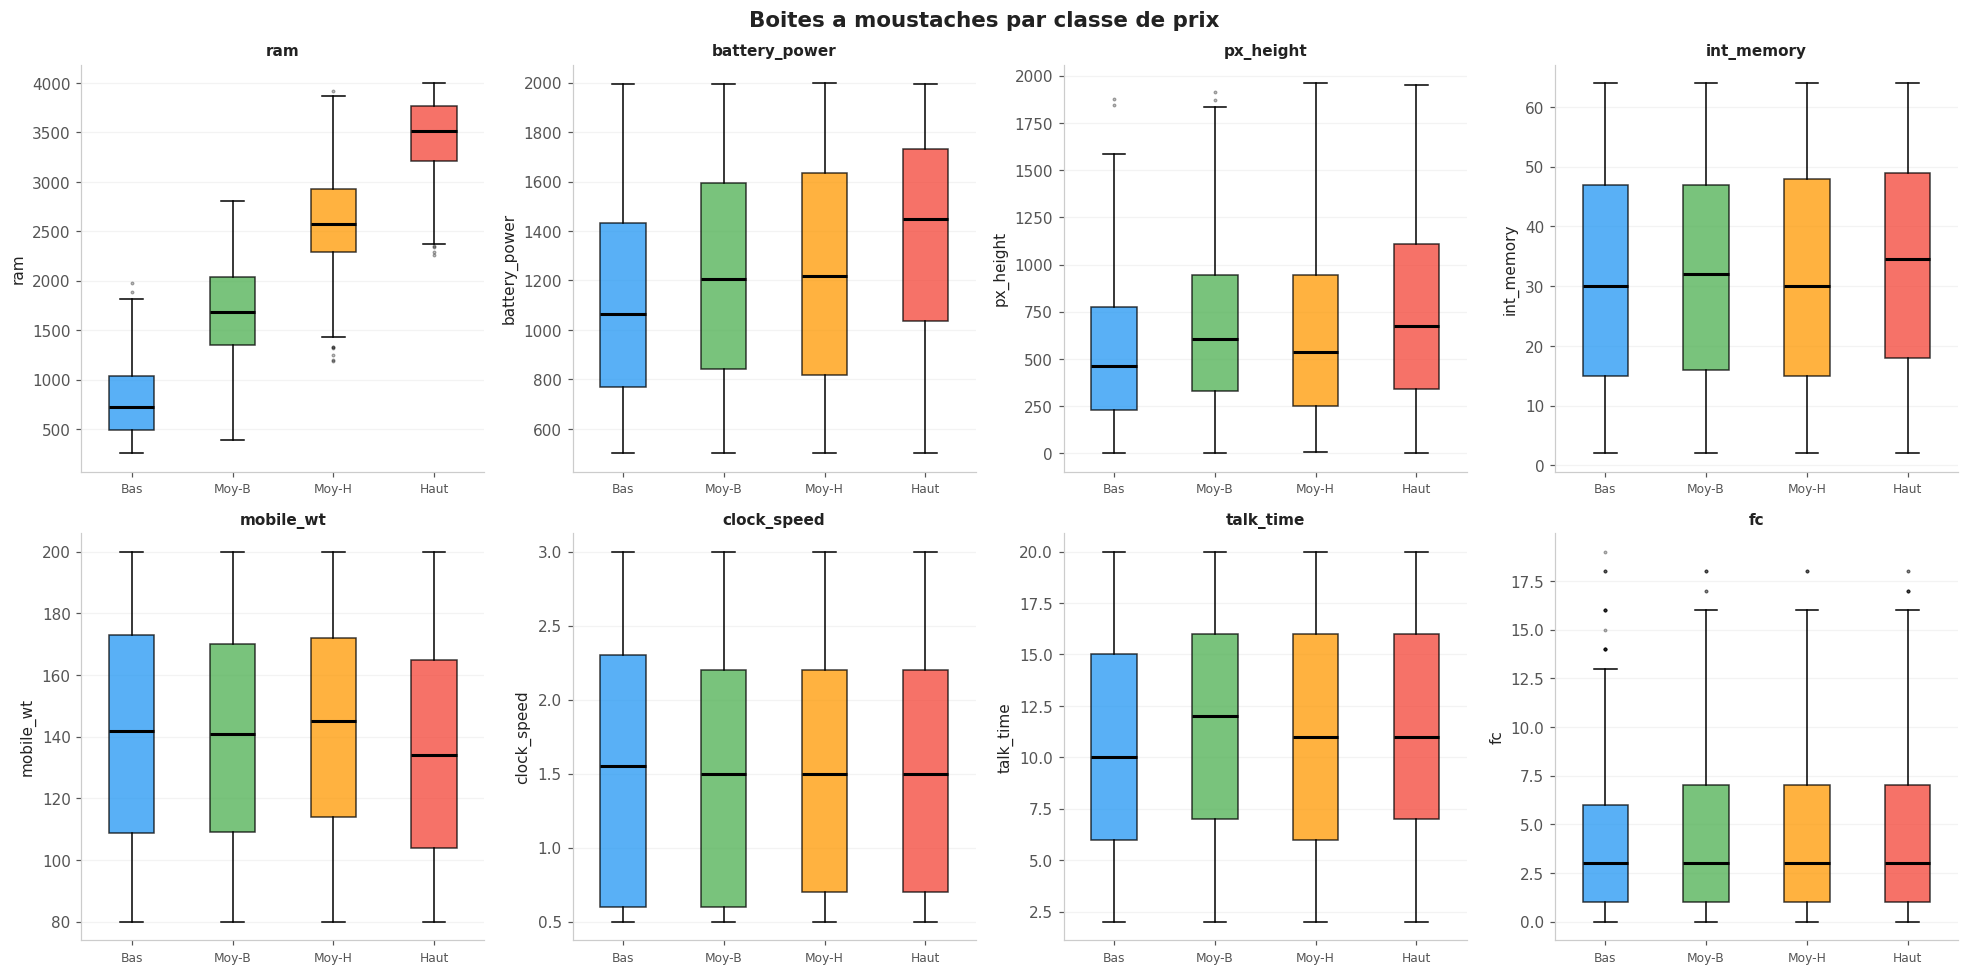

In [15]:
vars_box = ["ram", "battery_power", "px_height", "int_memory",
            "mobile_wt", "clock_speed", "talk_time", "fc"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Boites a moustaches par classe de prix",
             fontsize=14, fontweight="bold")

for ax, col in zip(axes.flat, vars_box):
    donnees = [df.loc[df["price_range"] == k, col].values for k in range(4)]
    bp = ax.boxplot(donnees, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2),
                    flierprops=dict(marker=".", markersize=3, alpha=0.4))
    for patch, k in zip(bp["boxes"], range(4)):
        patch.set_facecolor(COULEURS_PRIX[k])
        patch.set_alpha(0.75)
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_xticklabels(["Bas", "Moy-B", "Moy-H", "Haut"], fontsize=8)
    ax.set_ylabel(col)
    ax.grid(True, axis="y")

plt.tight_layout()
plt.savefig("fig2_boxplots.png", bbox_inches="tight")
plt.show()


### 4.3 Nuages de points — RAM et Résolution vs Prix

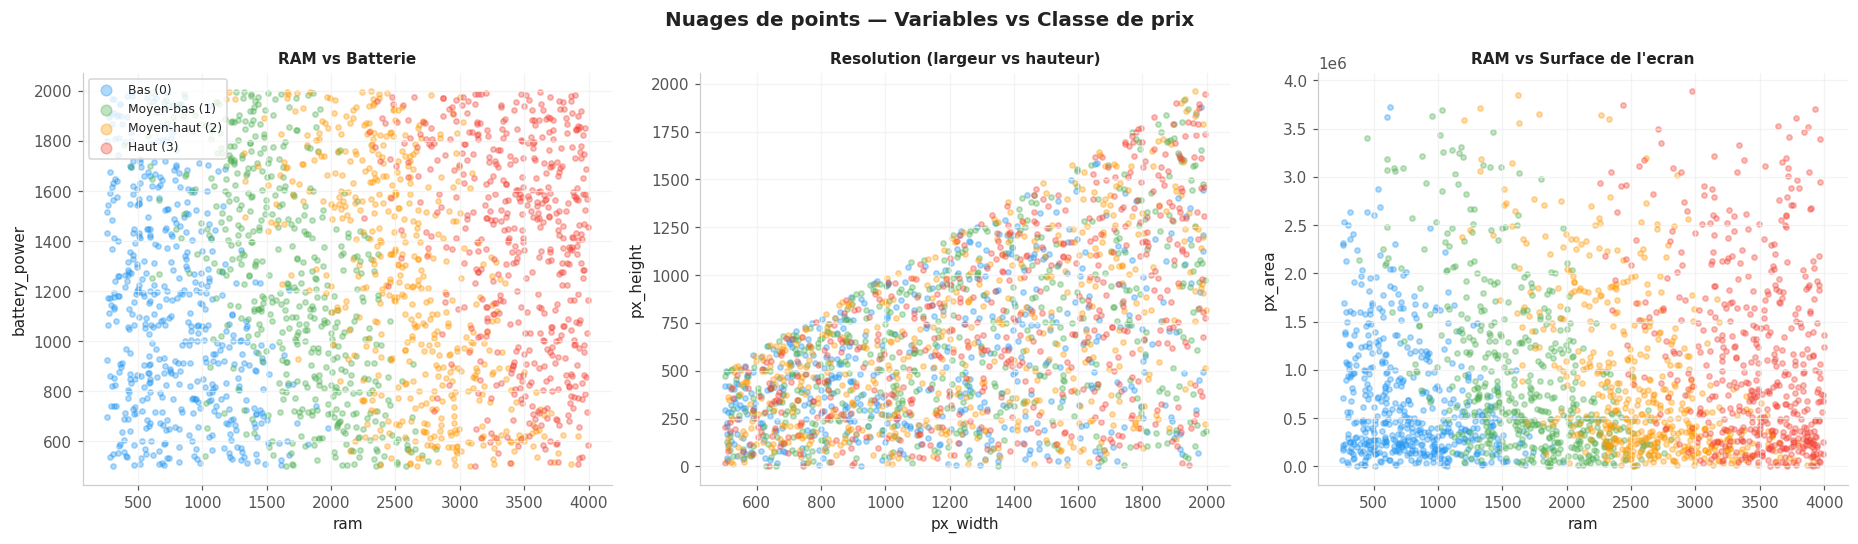

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Nuages de points — Variables vs Classe de prix",
             fontsize=13, fontweight="bold")

paires = [
    ("ram",           "battery_power", "RAM vs Batterie"),
    ("px_width",      "px_height",     "Resolution (largeur vs hauteur)"),
    ("ram",           "px_area",       "RAM vs Surface de l'ecran"),
]

for ax, (x_col, y_col, titre) in zip(axes, paires):
    for classe in range(4):
        sous = df[df["price_range"] == classe]
        ax.scatter(sous[x_col], sous[y_col],
                   color=COULEURS_PRIX[classe], alpha=0.35, s=12,
                   label=LABELS_PRIX[classe])
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(titre, fontsize=10, fontweight="bold")
    ax.grid(True)

axes[0].legend(fontsize=8, markerscale=2)
plt.tight_layout()
plt.savefig("fig3_scatter.png", bbox_inches="tight")
plt.show()


### 4.4 Carte de chaleur des corrélations

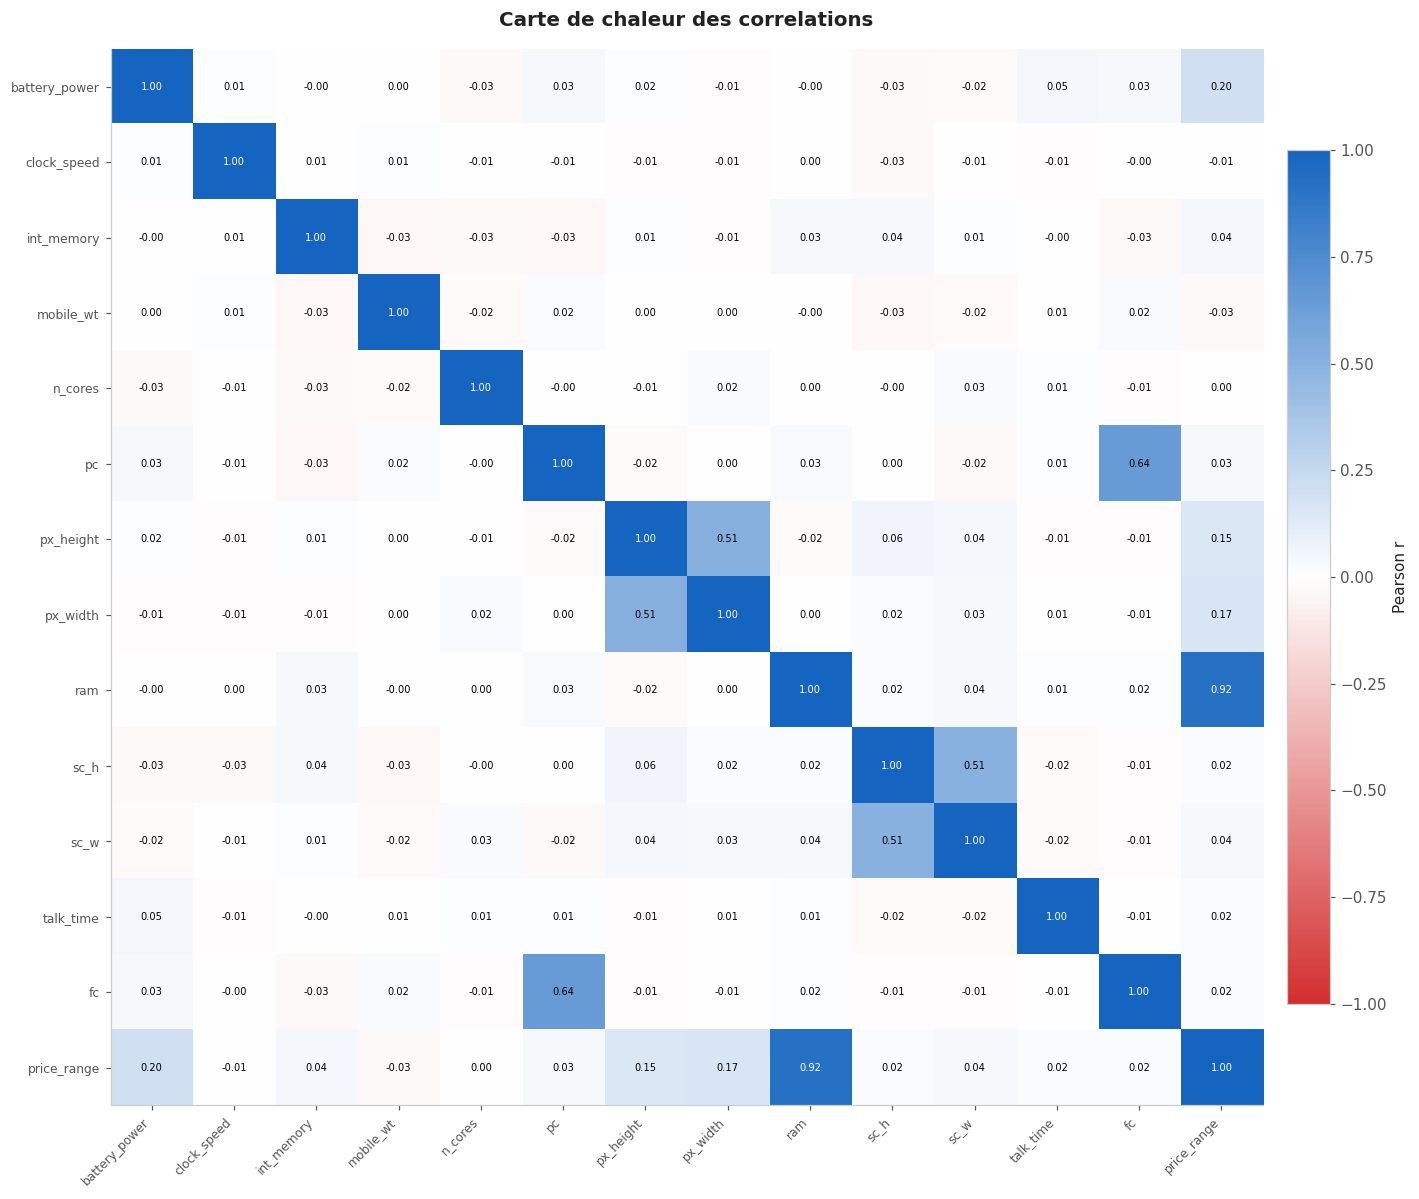

In [17]:
vars_corr = ["battery_power", "clock_speed", "int_memory", "mobile_wt",
             "n_cores", "pc", "px_height", "px_width", "ram",
             "sc_h", "sc_w", "talk_time", "fc", "price_range"]

matrice_corr = df[vars_corr].corr()

# Colormap personnalisee
cmap_corr = LinearSegmentedColormap.from_list(
    "corr", ["#d32f2f", "#ffffff", "#1565c0"], N=256
)

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(matrice_corr.values, cmap=cmap_corr, vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(vars_corr)))
ax.set_yticks(range(len(vars_corr)))
ax.set_xticklabels(vars_corr, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(vars_corr, fontsize=8)
ax.set_title("Carte de chaleur des correlations", fontsize=13, fontweight="bold", pad=15)

for i in range(len(vars_corr)):
    for j in range(len(vars_corr)):
        val = matrice_corr.values[i, j]
        couleur_txt = "white" if abs(val) > 0.65 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=6.5, color=couleur_txt)

plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02, label="Pearson r")
plt.tight_layout()
plt.savefig("fig4_heatmap.png", bbox_inches="tight")
plt.show()


### 4.5 Variables binaires — Taux de présence par classe de prix

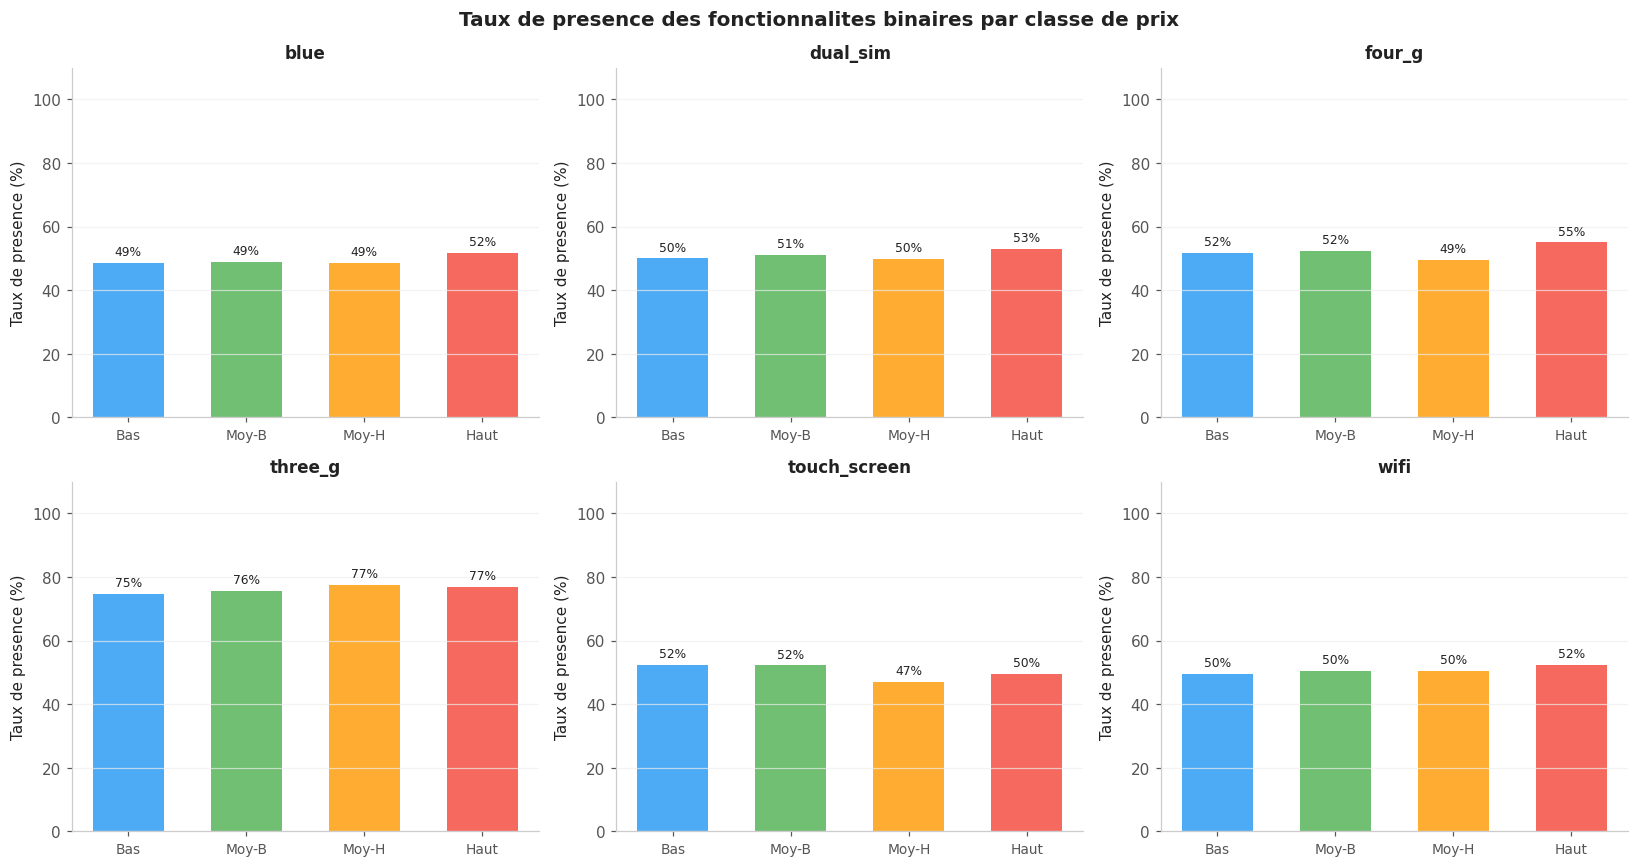

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Taux de presence des fonctionnalites binaires par classe de prix",
             fontsize=13, fontweight="bold")

for ax, col in zip(axes.flat, binaires):
    taux = df.groupby("price_range")[col].mean() * 100
    couleurs = [COULEURS_PRIX[k] for k in range(4)]
    barres = ax.bar(range(4), taux.values, color=couleurs, alpha=0.80, width=0.6)
    ax.set_xticks(range(4))
    ax.set_xticklabels(["Bas", "Moy-B", "Moy-H", "Haut"], fontsize=9)
    ax.set_ylabel("Taux de presence (%)")
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_ylim(0, 110)
    ax.grid(True, axis="y")
    for barre, val in zip(barres, taux.values):
        ax.text(barre.get_x() + barre.get_width() / 2,
                barre.get_height() + 1.5,
                f"{val:.0f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("fig5_binaires.png", bbox_inches="tight")
plt.show()


### 4.6 Tableau de bord récapitulatif

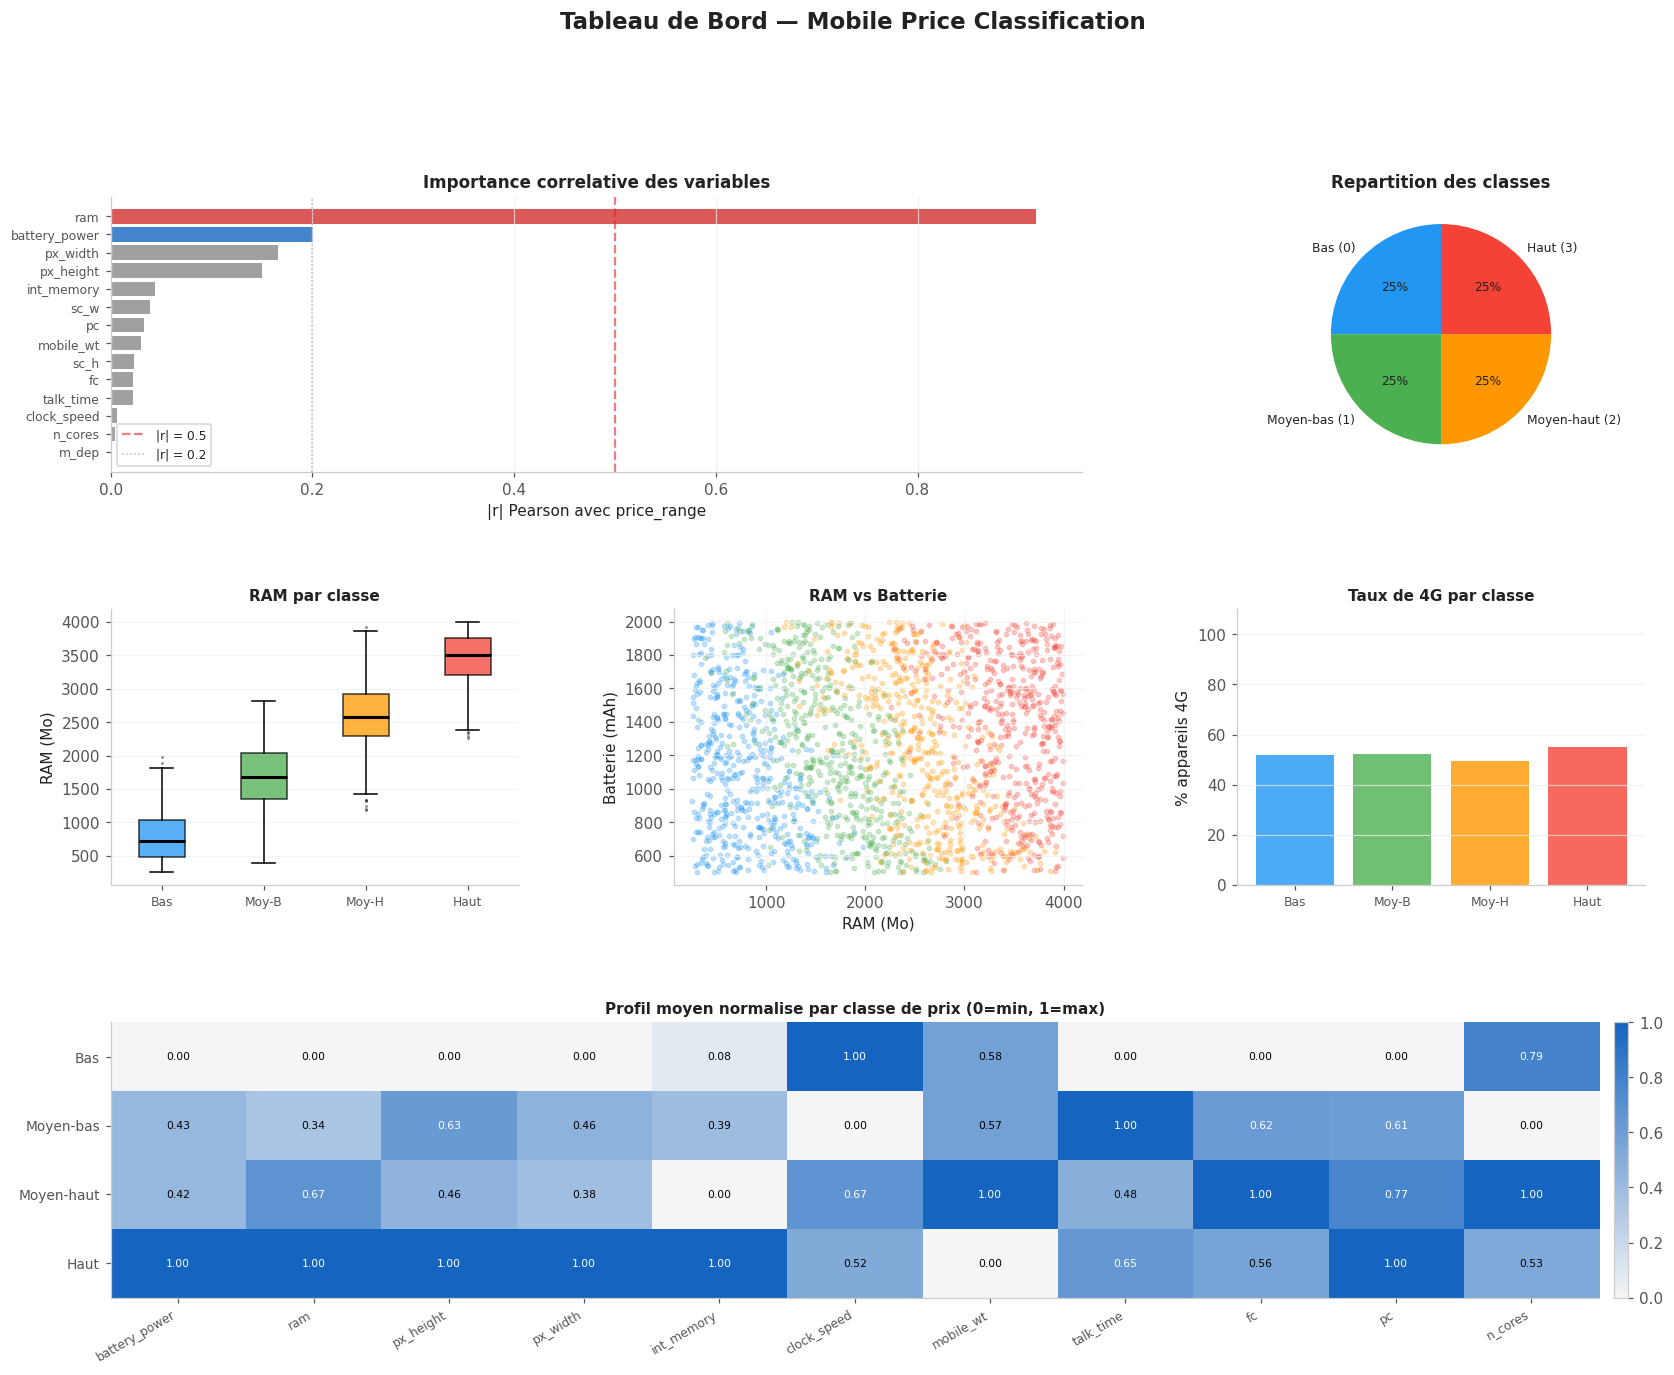

Tableau de bord genere.


In [19]:
fig = plt.figure(figsize=(18, 13))
fig.suptitle("Tableau de Bord — Mobile Price Classification",
             fontsize=15, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

# Panel 1 : Correlation avec price_range (barplot)
ax1 = fig.add_subplot(gs[0, :2])
corrs = df[continues].corrwith(df["price_range"]).abs().sort_values(ascending=True)
couleurs_bar = ["#d32f2f" if c > 0.5 else "#1565c0" if c > 0.2 else "#888888"
                for c in corrs.values]
ax1.barh(range(len(corrs)), corrs.values, color=couleurs_bar, alpha=0.80)
ax1.set_yticks(range(len(corrs)))
ax1.set_yticklabels(corrs.index, fontsize=8)
ax1.axvline(0.5, color="#d32f2f", linewidth=1.5, linestyle="--", alpha=0.6, label="|r| = 0.5")
ax1.axvline(0.2, color="#888888", linewidth=1,   linestyle=":",  alpha=0.6, label="|r| = 0.2")
ax1.set_xlabel("|r| Pearson avec price_range")
ax1.set_title("Importance correlative des variables", fontsize=11, fontweight="bold")
ax1.legend(fontsize=8)
ax1.grid(True, axis="x")

# Panel 2 : Repartition de la cible
ax2 = fig.add_subplot(gs[0, 2])
comptages = df["price_range"].value_counts().sort_index()
ax2.pie(comptages.values,
        labels=[LABELS_PRIX[k] for k in range(4)],
        colors=[COULEURS_PRIX[k] for k in range(4)],
        autopct="%1.0f%%", startangle=90,
        textprops={"fontsize": 8})
ax2.set_title("Repartition des classes", fontsize=11, fontweight="bold")

# Panel 3 : Boxplot RAM
ax3 = fig.add_subplot(gs[1, 0])
donnees_ram = [df.loc[df["price_range"] == k, "ram"].values for k in range(4)]
bp = ax3.boxplot(donnees_ram, patch_artist=True,
                  medianprops=dict(color="black", linewidth=2),
                  flierprops=dict(marker=".", markersize=2, alpha=0.4))
for patch, k in zip(bp["boxes"], range(4)):
    patch.set_facecolor(COULEURS_PRIX[k])
    patch.set_alpha(0.75)
ax3.set_xticklabels(["Bas", "Moy-B", "Moy-H", "Haut"], fontsize=8)
ax3.set_ylabel("RAM (Mo)")
ax3.set_title("RAM par classe", fontsize=10, fontweight="bold")
ax3.grid(True, axis="y")

# Panel 4 : Scatter RAM vs battery_power
ax4 = fig.add_subplot(gs[1, 1])
for classe in range(4):
    sous = df[df["price_range"] == classe]
    ax4.scatter(sous["ram"], sous["battery_power"],
                color=COULEURS_PRIX[classe], alpha=0.25, s=8)
ax4.set_xlabel("RAM (Mo)")
ax4.set_ylabel("Batterie (mAh)")
ax4.set_title("RAM vs Batterie", fontsize=10, fontweight="bold")
ax4.grid(True)

# Panel 5 : Taux 4G par classe
ax5 = fig.add_subplot(gs[1, 2])
taux_4g = df.groupby("price_range")["four_g"].mean() * 100
ax5.bar(range(4), taux_4g.values,
        color=[COULEURS_PRIX[k] for k in range(4)], alpha=0.80)
ax5.set_xticks(range(4))
ax5.set_xticklabels(["Bas", "Moy-B", "Moy-H", "Haut"], fontsize=8)
ax5.set_ylabel("% appareils 4G")
ax5.set_title("Taux de 4G par classe", fontsize=10, fontweight="bold")
ax5.set_ylim(0, 110)
ax5.grid(True, axis="y")

# Panel 6 : Moyenne de chaque variable par classe (heatmap normalisee)
ax6 = fig.add_subplot(gs[2, :])
vars_norm = ["battery_power", "ram", "px_height", "px_width", "int_memory",
             "clock_speed", "mobile_wt", "talk_time", "fc", "pc", "n_cores"]
moyennes = df.groupby("price_range")[vars_norm].mean()
moyennes_norm = (moyennes - moyennes.min()) / (moyennes.max() - moyennes.min())

cmap2 = LinearSegmentedColormap.from_list("norm", ["#f5f5f5", "#1565c0"], N=256)
im6 = ax6.imshow(moyennes_norm.values, cmap=cmap2, vmin=0, vmax=1, aspect="auto")
ax6.set_xticks(range(len(vars_norm)))
ax6.set_yticks(range(4))
ax6.set_xticklabels(vars_norm, rotation=30, ha="right", fontsize=8)
ax6.set_yticklabels(["Bas", "Moyen-bas", "Moyen-haut", "Haut"], fontsize=9)
ax6.set_title("Profil moyen normalise par classe de prix (0=min, 1=max)",
              fontsize=10, fontweight="bold")
for i in range(4):
    for j in range(len(vars_norm)):
        ax6.text(j, i, f"{moyennes_norm.values[i, j]:.2f}",
                 ha="center", va="center", fontsize=7,
                 color="white" if moyennes_norm.values[i, j] > 0.6 else "black")
plt.colorbar(im6, ax=ax6, fraction=0.02, pad=0.01)

plt.savefig("fig6_dashboard.png", bbox_inches="tight")
plt.show()
print("Tableau de bord genere.")


---
## 5. Synthèse, Insights et Conclusions

### 5.1 Tableau récapitulatif des tests statistiques


In [ ]:

print()
print("1. Corrélations Pearson avec price_range :")
corrs_finales = df[continues].corrwith(df["price_range"]).abs().sort_values(ascending=False)
for feat, val in corrs_finales.head(6).items():
    barre = "#" * int(val * 30)
    print(f"   {feat:<18} r={val:.3f}  {barre}")

print()
print("2. ANOVA — toutes les variables continues testees sont")
print("   significativement differentes entre classes (p < 0.001)")
print()
print("3. Chi2 — variables binaires significativement associees :")
print("   four_g, three_g  (p < 0.001)")
print("   Non significatifs : blue, dual_sim, touch_screen, wifi")
print()
print("4. Test de Levene — variabilite de la RAM :")
print("   Variances heterogenes entre classes (p < 0.001)")
print("   Interpretation : la RAM est concentree differemment selon la gamme")
print()
print("5. Normalite des rendements :")
stat, p = normaltest(df["ram"])
print("   Test D'Agostino sur la RAM : stat={:.2f}, p={:.4f}  -> {}".format(
    stat, p, "Non normale" if p < 0.05 else "Normale"))


SYNTHESE DES TESTS STATISTIQUES

1. Corrélations Pearson avec price_range :
   ram                r=0.917  ###########################
   battery_power      r=0.201  ######
   px_width           r=0.166  ####
   px_height          r=0.150  ####
   int_memory         r=0.044  #
   sc_w               r=0.039  #

2. ANOVA — toutes les variables continues testees sont
   significativement differentes entre classes (p < 0.001)

3. Chi2 — variables binaires significativement associees :
   four_g, three_g  (p < 0.001)
   Non significatifs : blue, dual_sim, touch_screen, wifi

4. Test de Levene — variabilite de la RAM :
   Variances heterogenes entre classes (p < 0.001)
   Interpretation : la RAM est concentree differemment selon la gamme

5. Normalite des rendements :
   Test D'Agostino sur la RAM : stat=1500.58, p=0.0000  -> Non normale
